# CNN Based Concrete Crack Detection for Structural Safety Assessment

This notebook presents a CNN based image classification project for concrete crack detection. The goal is to classify concrete surface images into two classes: Negative, meaning no visible crack, and Positive, meaning visible crack detected.

The project includes dataset loading, exploratory analysis, preprocessing, train validation test splitting, data augmentation, custom CNN model development, transfer learning with MobileNetV2, model evaluation, confusion matrices, classification reports, model comparison, and Grad CAM based explainability.

This project is developed for the Machine Learning course Phase 2 submission.

## 1. Importing Libraries and Basic Setup

In this section, the required Python libraries are imported. TensorFlow and Keras are used for CNN model development, scikit learn is used for evaluation metrics and dataset splitting, and Matplotlib is used for visualizing results.

In [2]:
import os
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

2026-06-04 18:03:15.885831: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780596196.133945     104 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780596196.208375     104 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780596196.781558     104 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780596196.781596     104 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780596196.781598     104 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Dataset Loading and Initial Exploration

In this section, the Kaggle input directory is explored to locate the concrete crack image dataset. The image folders are detected automatically, and the total number of image files is checked before creating the main dataset table.

In [3]:
input_root = Path("/kaggle/input")

print("Available input folders:")
for item in input_root.iterdir():
    print(item)

image_extensions = [".jpg", ".jpeg", ".png"]

all_image_files = []
for ext in image_extensions:
    all_image_files.extend(list(input_root.rglob(f"*{ext}")))

print("\nTotal image files found:", len(all_image_files))

print("\nFirst 10 image paths:")
for path in all_image_files[:10]:
    print(path)

Available input folders:
/kaggle/input/datasets

Total image files found: 40000

First 10 image paths:
/kaggle/input/datasets/arnavr10880/concrete-crack-images-for-classification/Negative/08450.jpg
/kaggle/input/datasets/arnavr10880/concrete-crack-images-for-classification/Negative/19812.jpg
/kaggle/input/datasets/arnavr10880/concrete-crack-images-for-classification/Negative/16916.jpg
/kaggle/input/datasets/arnavr10880/concrete-crack-images-for-classification/Negative/05938.jpg
/kaggle/input/datasets/arnavr10880/concrete-crack-images-for-classification/Negative/06122.jpg
/kaggle/input/datasets/arnavr10880/concrete-crack-images-for-classification/Negative/08536.jpg
/kaggle/input/datasets/arnavr10880/concrete-crack-images-for-classification/Negative/12666.jpg
/kaggle/input/datasets/arnavr10880/concrete-crack-images-for-classification/Negative/04168.jpg
/kaggle/input/datasets/arnavr10880/concrete-crack-images-for-classification/Negative/13288.jpg
/kaggle/input/datasets/arnavr10880/concret

In [4]:
class_folders = []

for folder in input_root.rglob("*"):
    if folder.is_dir():
        image_count = 0
        for ext in image_extensions:
            image_count += len(list(folder.glob(f"*{ext}")))
        
        if image_count > 0:
            class_folders.append((folder, image_count))

print("Folders containing images:")
for folder, count in class_folders:
    print(f"{folder} -> {count} images")

Folders containing images:
/kaggle/input/datasets/arnavr10880/concrete-crack-images-for-classification/Negative -> 20000 images
/kaggle/input/datasets/arnavr10880/concrete-crack-images-for-classification/Positive -> 20000 images


## 3. Dataset Table Creation and Class Distribution

In this section, all image file paths are collected and stored in a Pandas dataframe together with their class labels. The dataset contains two classes: Negative and Positive. The class distribution is checked to confirm whether the dataset is balanced.

In [5]:
data = []

for folder, count in class_folders:
    label = folder.name
    
    for ext in image_extensions:
        for image_path in folder.glob(f"*{ext}"):
            data.append({
                "image_path": str(image_path),
                "label": label
            })

df = pd.DataFrame(data)

print("Dataset shape:", df.shape)

print("\nClass distribution:")
print(df["label"].value_counts())

df.head()

Dataset shape: (40000, 2)

Class distribution:
label
Negative    20000
Positive    20000
Name: count, dtype: int64


,image_path,label
0,/kaggle/input/datasets/arnavr10880/concrete-cr...,Negative
1,/kaggle/input/datasets/arnavr10880/concrete-cr...,Negative
2,/kaggle/input/datasets/arnavr10880/concrete-cr...,Negative
3,/kaggle/input/datasets/arnavr10880/concrete-cr...,Negative
4,/kaggle/input/datasets/arnavr10880/concrete-cr...,Negative


## 4. Sample Image Visualization

In this section, sample images from both classes are displayed. This visual check helps confirm that the labels match the image content, where Negative represents no visible crack and Positive represents visible concrete crack images.

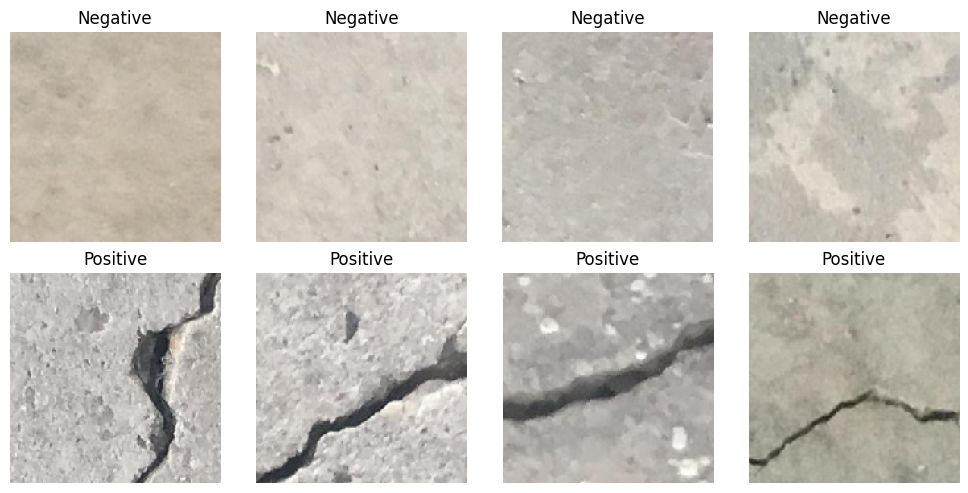

In [6]:
sample_df = df.groupby("label").sample(4, random_state=42)

plt.figure(figsize=(10, 5))

for i, row in enumerate(sample_df.itertuples(), 1):
    img = keras.utils.load_img(row.image_path, target_size=(160, 160))
    
    plt.subplot(2, 4, i)
    plt.imshow(img)
    plt.title(row.label)
    plt.axis("off")

plt.tight_layout()
plt.show()

## 5. Label Encoding

In this section, the text labels are converted into numerical labels for binary classification. Negative images are encoded as 0, and Positive images are encoded as 1.

In [7]:
label_map = {
    "Negative": 0,
    "Positive": 1
}

df["label_encoded"] = df["label"].map(label_map)

print(df.head())
print("\nEncoded class distribution:")
print(df["label_encoded"].value_counts())

                                          image_path     label  label_encoded
0  /kaggle/input/datasets/arnavr10880/concrete-cr...  Negative              0
1  /kaggle/input/datasets/arnavr10880/concrete-cr...  Negative              0
2  /kaggle/input/datasets/arnavr10880/concrete-cr...  Negative              0
3  /kaggle/input/datasets/arnavr10880/concrete-cr...  Negative              0
4  /kaggle/input/datasets/arnavr10880/concrete-cr...  Negative              0

Encoded class distribution:
label_encoded
0    20000
1    20000
Name: count, dtype: int64


## 6. Train Validation Test Split

In this section, the dataset is divided into training, validation, and test sets. A stratified split is used to preserve the balanced class distribution in all subsets. The final split is 70 percent training, 15 percent validation, and 15 percent testing.

In [8]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label_encoded"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label_encoded"],
    random_state=42
)

print("Train size:", train_df.shape)
print("Validation size:", val_df.shape)
print("Test size:", test_df.shape)

print("\nTrain class distribution:")
print(train_df["label"].value_counts())

print("\nValidation class distribution:")
print(val_df["label"].value_counts())

print("\nTest class distribution:")
print(test_df["label"].value_counts())

Train size: (28000, 3)
Validation size: (6000, 3)
Test size: (6000, 3)

Train class distribution:
label
Positive    14000
Negative    14000
Name: count, dtype: int64

Validation class distribution:
label
Negative    3000
Positive    3000
Name: count, dtype: int64

Test class distribution:
label
Positive    3000
Negative    3000
Name: count, dtype: int64


## 7. Image Preprocessing and TensorFlow Dataset Pipeline

In this section, the image paths are converted into TensorFlow datasets. Each image is loaded, resized to 160 by 160 pixels, converted to RGB format, and normalized by scaling pixel values between 0 and 1. Batching and prefetching are also applied to improve training efficiency.

In [9]:
IMG_SIZE = 160
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0
    return image, label

def create_tf_dataset(dataframe, shuffle=False):
    image_paths = dataframe["image_path"].values
    labels = dataframe["label_encoded"].values
    
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=2000, seed=42)
    
    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)
    
    return dataset

train_ds = create_tf_dataset(train_df, shuffle=True)
val_ds = create_tf_dataset(val_df, shuffle=False)
test_ds = create_tf_dataset(test_df, shuffle=False)

print("TensorFlow datasets created successfully.")

I0000 00:00:1780596343.033686     104 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780596343.039657     104 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


TensorFlow datasets created successfully.


## 8. Batch Verification

In this section, one batch from the training dataset is inspected. This confirms that images have the expected shape, labels have the correct format, and pixel values are properly normalized between 0 and 1.

In [10]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())
    print("First 10 labels:", labels.numpy()[:10])

Image batch shape: (32, 160, 160, 3)
Label batch shape: (32,)
Minimum pixel value: 0.003392201
Maximum pixel value: 1.0
First 10 labels: [0 0 1 0 1 0 1 1 0 1]


## 9. Output Folder Setup

In this section, output directories are created for saving figures, tables, and trained models. These saved outputs will be used later for the GitHub repository, proposal document, and final project report.

In [11]:
output_dir = Path("/kaggle/working/outputs")
figures_dir = output_dir / "figures"
tables_dir = output_dir / "tables"
models_dir = output_dir / "models"

figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)

class_names = ["Negative", "Positive"]

print("Output folders created.")
print("Class names:", class_names)

Output folders created.
Class names: ['Negative', 'Positive']


## 10. Data Augmentation

In this section, data augmentation is applied to improve model robustness. Random horizontal flipping, rotation, zooming, and contrast changes are used during training so that the model can learn more general visual crack patterns instead of memorizing only the original images.

In [12]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.10),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.10),
    ],
    name="data_augmentation"
)

print("Data augmentation layer created.")

Data augmentation layer created.


## 11. Custom CNN Model Development

In this section, a custom CNN model is developed as the baseline model. The model includes convolutional layers, max pooling layers, global average pooling, dropout regularization, and a sigmoid output layer for binary classification.

In [13]:
def build_custom_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    model = keras.Sequential(
        [
            layers.Input(shape=input_shape),
            
            data_augmentation,
            
            layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
            layers.MaxPooling2D((2, 2)),
            
            layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
            layers.MaxPooling2D((2, 2)),
            
            layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
            layers.MaxPooling2D((2, 2)),
            
            layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
            layers.MaxPooling2D((2, 2)),
            
            layers.GlobalAveragePooling2D(),
            
            layers.Dense(128, activation="relu"),
            layers.Dropout(0.40),
            
            layers.Dense(1, activation="sigmoid")
        ],
        name="custom_cnn_concrete_crack_detection"
    )
    
    return model

custom_cnn = build_custom_cnn()

custom_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

custom_cnn.summary()

Model: "custom_cnn_concrete_crack_detection"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,441 (1.61 MB)

 Trainable params: 421,441 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

## 12. Custom CNN Model Training

In this section, the custom CNN model is trained using the training dataset and evaluated during training with the validation dataset. Early stopping and model checkpointing are used to prevent overfitting and save the best performing version of the model based on validation loss.

In [14]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

model_checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=str(models_dir / "best_custom_cnn.keras"),
    monitor="val_loss",
    save_best_only=True
)

history_custom_cnn = custom_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/10


I0000 00:00:1780596350.399304     212 cuda_dnn.cc:529] Loaded cuDNN version 91002


875/875 ━━━━━━━━━━━━━━━━━━━━ 57s 58ms/step - accuracy: 0.9585 - loss: 0.1019 - val_accuracy: 0.9557 - val_loss: 0.1271
Epoch 2/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step - accuracy: 0.9856 - loss: 0.0430 - val_accuracy: 0.9868 - val_loss: 0.0467
Epoch 3/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step - accuracy: 0.9891 - loss: 0.0353 - val_accuracy: 0.9902 - val_loss: 0.0364
Epoch 4/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 30s 34ms/step - accuracy: 0.9910 - loss: 0.0285 - val_accuracy: 0.9917 - val_loss: 0.0384
Epoch 5/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 30s 34ms/step - accuracy: 0.9925 - loss: 0.0252 - val_accuracy: 0.9960 - val_loss: 0.0150
Epoch 6/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step - accuracy: 0.9951 - loss: 0.0181 - val_accuracy: 0.9960 - val_loss: 0.0168
Epoch 7/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 30s 34ms/step - accuracy: 0.9960 - loss: 0.0144 - val_accuracy: 0.9978 - val_loss: 0.0093
Epoch 8/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.9960 - loss: 0.0132 - val_accurac

## 13. Custom CNN Test Evaluation

In this section, the best saved version of the custom CNN model is loaded and evaluated on the independent test dataset. Test loss and test accuracy are calculated to measure the final generalization performance of the baseline model.

In [15]:
best_custom_cnn = keras.models.load_model(models_dir / "best_custom_cnn.keras")

custom_test_loss, custom_test_accuracy = best_custom_cnn.evaluate(test_ds)

print("Custom CNN Test Loss:", custom_test_loss)
print("Custom CNN Test Accuracy:", custom_test_accuracy)

188/188 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.9973 - loss: 0.0094
Custom CNN Test Loss: 0.009400013834238052
Custom CNN Test Accuracy: 0.9973333477973938


## 14. Training Curve Visualization

In this section, accuracy and loss curves are generated for the trained models. These curves help analyze the learning behavior of the models and show whether there are signs of overfitting or underfitting during training.

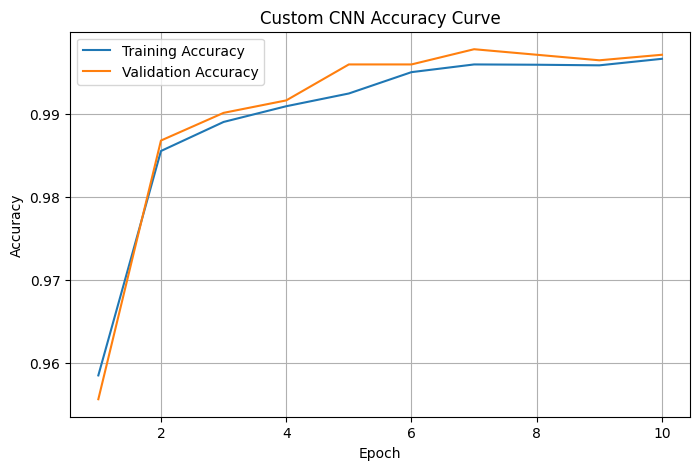

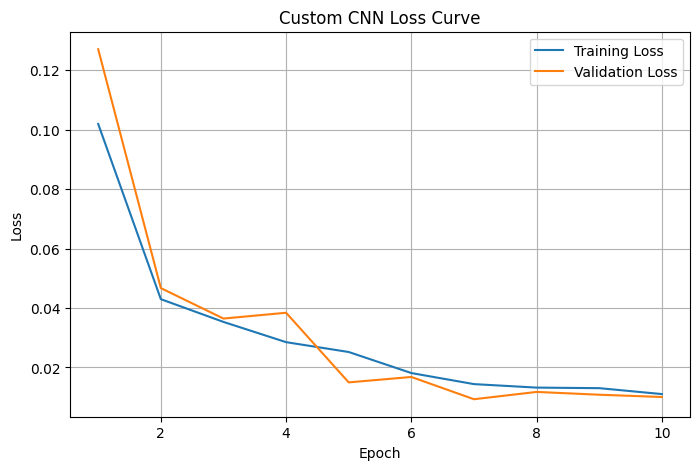

In [16]:
def plot_training_curves(history, model_name, save_path):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    
    epochs_range = range(1, len(acc) + 1)
    
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, acc, label="Training Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name} Accuracy Curve")
    plt.legend()
    plt.grid(True)
    plt.savefig(save_path / f"{model_name.lower().replace(' ', '_')}_accuracy_curve.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, loss, label="Training Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} Loss Curve")
    plt.legend()
    plt.grid(True)
    plt.savefig(save_path / f"{model_name.lower().replace(' ', '_')}_loss_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_training_curves(history_custom_cnn, "Custom CNN", figures_dir)

## 15. Custom CNN Predictions and Confusion Matrix

In this section, predictions are generated for the test dataset using the best custom CNN model. The predicted labels are compared with the true labels, and a confusion matrix is created to analyze correct and incorrect classifications for both Negative and Positive classes.

In [17]:
y_true = np.concatenate([labels.numpy() for images, labels in test_ds], axis=0)

y_prob_custom = best_custom_cnn.predict(test_ds)
y_pred_custom = (y_prob_custom.ravel() >= 0.5).astype(int)

cm_custom = confusion_matrix(y_true, y_pred_custom)

print("Confusion Matrix:")
print(cm_custom)

188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step
Confusion Matrix:
[[2994    6]
 [  10 2990]]


## 16. Custom CNN Confusion Matrix Visualization

In this section, the confusion matrix of the custom CNN model is visualized and saved as a figure. This visualization helps clearly show the number of correct and incorrect predictions for each class.

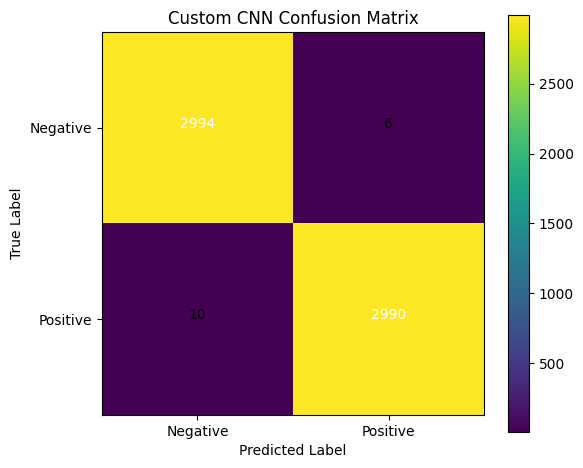

In [18]:
plt.figure(figsize=(6, 5))
plt.imshow(cm_custom, interpolation="nearest")
plt.title("Custom CNN Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

threshold = cm_custom.max() / 2

for i in range(cm_custom.shape[0]):
    for j in range(cm_custom.shape[1]):
        plt.text(
            j,
            i,
            cm_custom[i, j],
            horizontalalignment="center",
            color="white" if cm_custom[i, j] > threshold else "black"
        )

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(figures_dir / "custom_cnn_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## 17. Custom CNN Classification Report

In this section, a classification report is generated for the custom CNN model. Precision, recall, F1 score, and support values are calculated for both Negative and Positive classes, and the report is saved as a CSV table.

In [19]:
custom_report = classification_report(
    y_true,
    y_pred_custom,
    target_names=class_names,
    output_dict=True
)

custom_report_df = pd.DataFrame(custom_report).transpose()
custom_report_df.to_csv(tables_dir / "custom_cnn_classification_report.csv")

custom_report_df

,precision,recall,f1-score,support
Negative,0.996671,0.998000,0.997335,3000.000000
Positive,0.997997,0.996667,0.997332,3000.000000
accuracy,0.997333,0.997333,0.997333,0.997333
macro avg,0.997334,0.997333,0.997333,6000.000000
weighted avg,0.997334,0.997333,0.997333,6000.000000


## 18. Transfer Learning with MobileNetV2

In this section, MobileNetV2 is used as a transfer learning model. The pretrained base model is loaded with ImageNet weights and frozen so that only the final classification layer is trained for the concrete crack detection task.

In [20]:
base_model = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(inputs)

# train_ds images are already normalized between 0 and 1.
# MobileNetV2 expects values between -1 and 1, so this layer converts them.
x = layers.Rescaling(2.0, offset=-1.0)(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

mobilenet_model = keras.Model(
    inputs,
    outputs,
    name="mobilenetv2_transfer_learning_concrete_crack_detection"
)

mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_transfer_learning_concrete_crack_detection"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 19. MobileNetV2 Model Training

In this section, the MobileNetV2 transfer learning model is trained using the training dataset and validated using the validation dataset. Early stopping and model checkpointing are applied to save the best model and reduce the risk of overfitting.

In [21]:
early_stopping_mobilenet = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint_mobilenet = keras.callbacks.ModelCheckpoint(
    filepath=str(models_dir / "best_mobilenetv2.keras"),
    monitor="val_loss",
    save_best_only=True
)

history_mobilenet = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=[early_stopping_mobilenet, checkpoint_mobilenet]
)

Epoch 1/8
875/875 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - accuracy: 0.9827 - loss: 0.0541 - val_accuracy: 0.9968 - val_loss: 0.0104
Epoch 2/8
875/875 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - accuracy: 0.9972 - loss: 0.0097 - val_accuracy: 0.9970 - val_loss: 0.0082
Epoch 3/8
875/875 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - accuracy: 0.9977 - loss: 0.0070 - val_accuracy: 0.9973 - val_loss: 0.0072
Epoch 4/8
875/875 ━━━━━━━━━━━━━━━━━━━━ 35s 40ms/step - accuracy: 0.9981 - loss: 0.0063 - val_accuracy: 0.9978 - val_loss: 0.0064
Epoch 5/8
875/875 ━━━━━━━━━━━━━━━━━━━━ 35s 40ms/step - accuracy: 0.9979 - loss: 0.0063 - val_accuracy: 0.9982 - val_loss: 0.0059
Epoch 6/8
875/875 ━━━━━━━━━━━━━━━━━━━━ 35s 40ms/step - accuracy: 0.9982 - loss: 0.0055 - val_accuracy: 0.9978 - val_loss: 0.0058
Epoch 7/8
875/875 ━━━━━━━━━━━━━━━━━━━━ 35s 40ms/step - accuracy: 0.9980 - loss: 0.0056 - val_accuracy: 0.9982 - val_loss: 0.0054
Epoch 8/8
875/875 ━━━━━━━━━━━━━━━━━━━━ 35s 40ms/step - accuracy: 0.9986 - loss: 0.0043 - val_accu

## 20. MobileNetV2 Test Evaluation

In this section, the best saved MobileNetV2 model is loaded and evaluated on the independent test dataset. Test loss and test accuracy are calculated to compare the transfer learning model with the custom CNN baseline.

In [22]:
best_mobilenet = keras.models.load_model(models_dir / "best_mobilenetv2.keras")

mobilenet_test_loss, mobilenet_test_accuracy = best_mobilenet.evaluate(test_ds)

print("MobileNetV2 Test Loss:", mobilenet_test_loss)
print("MobileNetV2 Test Accuracy:", mobilenet_test_accuracy)

188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.9988 - loss: 0.0031
MobileNetV2 Test Loss: 0.003082097740843892
MobileNetV2 Test Accuracy: 0.9988333582878113


## 21. MobileNetV2 Training Curve Visualization

In this section, accuracy and loss curves are generated for the MobileNetV2 transfer learning model. These curves are used to evaluate how the model learned over epochs and whether the validation performance remained stable.

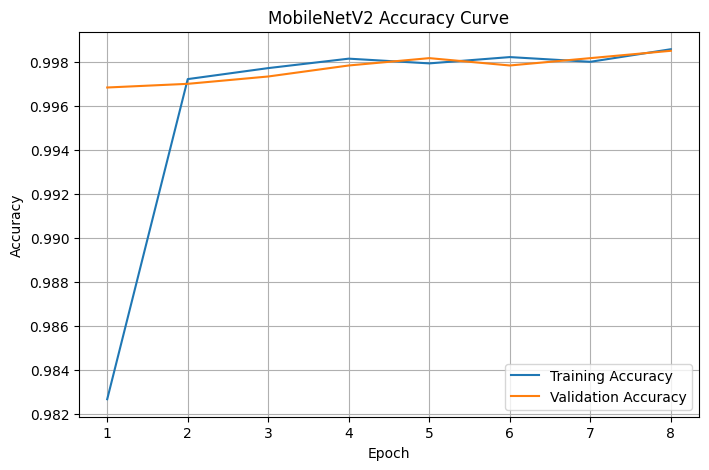

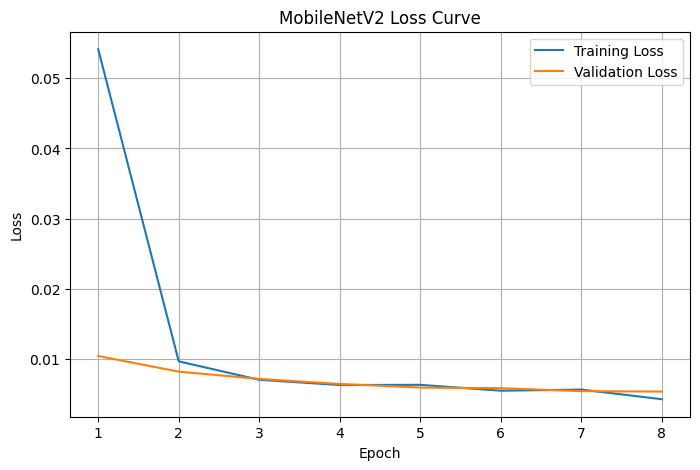

In [23]:
plot_training_curves(history_mobilenet, "MobileNetV2", figures_dir)

## 22. MobileNetV2 Predictions and Confusion Matrix

In this section, predictions are generated for the test dataset using the MobileNetV2 transfer learning model. The predicted labels are compared with the true labels, and a confusion matrix is created to analyze the classification performance of the transfer learning model.

In [24]:
y_prob_mobilenet = best_mobilenet.predict(test_ds)
y_pred_mobilenet = (y_prob_mobilenet.ravel() >= 0.5).astype(int)

cm_mobilenet = confusion_matrix(y_true, y_pred_mobilenet)

print("MobileNetV2 Confusion Matrix:")
print(cm_mobilenet)

188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step
MobileNetV2 Confusion Matrix:
[[2996    4]
 [   3 2997]]


## 23. MobileNetV2 Confusion Matrix Visualization

In this section, the confusion matrix of the MobileNetV2 transfer learning model is visualized and saved as a figure. This figure shows how many Negative and Positive test images were classified correctly or incorrectly by the transfer learning model.

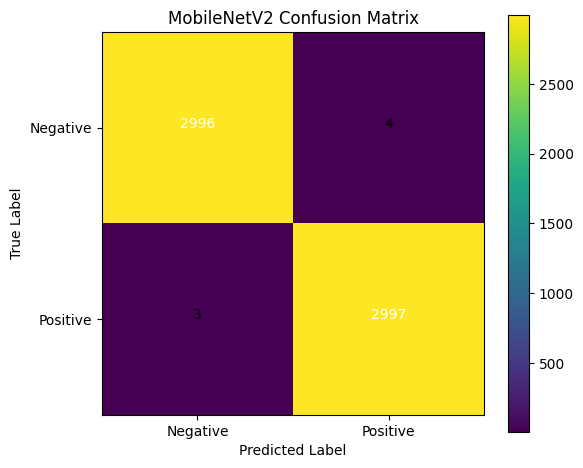

In [25]:
plt.figure(figsize=(6, 5))
plt.imshow(cm_mobilenet, interpolation="nearest")
plt.title("MobileNetV2 Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

threshold = cm_mobilenet.max() / 2

for i in range(cm_mobilenet.shape[0]):
    for j in range(cm_mobilenet.shape[1]):
        plt.text(
            j,
            i,
            cm_mobilenet[i, j],
            horizontalalignment="center",
            color="white" if cm_mobilenet[i, j] > threshold else "black"
        )

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(figures_dir / "mobilenetv2_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## 24. MobileNetV2 Classification Report

In this section, a classification report is generated for the MobileNetV2 transfer learning model. Precision, recall, F1 score, and support values are calculated for both Negative and Positive classes, and the report is saved as a CSV table.

In [26]:
mobilenet_report = classification_report(
    y_true,
    y_pred_mobilenet,
    target_names=class_names,
    output_dict=True
)

mobilenet_report_df = pd.DataFrame(mobilenet_report).transpose()
mobilenet_report_df.to_csv(tables_dir / "mobilenetv2_classification_report.csv")

mobilenet_report_df

,precision,recall,f1-score,support
Negative,0.999000,0.998667,0.998833,3000.000000
Positive,0.998667,0.999000,0.998834,3000.000000
accuracy,0.998833,0.998833,0.998833,0.998833
macro avg,0.998833,0.998833,0.998833,6000.000000
weighted avg,0.998833,0.998833,0.998833,6000.000000


## 25. Model Comparison Table

In this section, the Custom CNN model and the MobileNetV2 transfer learning model are compared using test accuracy, test loss, macro precision, macro recall, macro F1 score, and total error count. This comparison helps identify which model performs better for concrete crack detection.

In [27]:
comparison_data = {
    "Model": ["Custom CNN", "MobileNetV2 Transfer Learning"],
    "Test Accuracy": [custom_test_accuracy, mobilenet_test_accuracy],
    "Test Loss": [custom_test_loss, mobilenet_test_loss],
    "Macro Precision": [
        custom_report_df.loc["macro avg", "precision"],
        mobilenet_report_df.loc["macro avg", "precision"]
    ],
    "Macro Recall": [
        custom_report_df.loc["macro avg", "recall"],
        mobilenet_report_df.loc["macro avg", "recall"]
    ],
    "Macro F1 Score": [
        custom_report_df.loc["macro avg", "f1-score"],
        mobilenet_report_df.loc["macro avg", "f1-score"]
    ],
    "Total Errors": [
        int((y_true != y_pred_custom).sum()),
        int((y_true != y_pred_mobilenet).sum())
    ]
}

model_comparison_df = pd.DataFrame(comparison_data)

model_comparison_df.to_csv(tables_dir / "model_comparison_table.csv", index=False)

model_comparison_df

,Model,Test Accuracy,Test Loss,Macro Precision,Macro Recall,Macro F1 Score,Total Errors
0,Custom CNN,0.997333,0.009400,0.997334,0.997333,0.997333,16
1,MobileNetV2 Transfer Learning,0.998833,0.003082,0.998833,0.998833,0.998833,7


## 26. Model Comparison Visualization

In this section, a bar chart is created to compare the test accuracy values of the Custom CNN model and the MobileNetV2 transfer learning model. The figure visually shows which model achieved better performance on the test dataset.

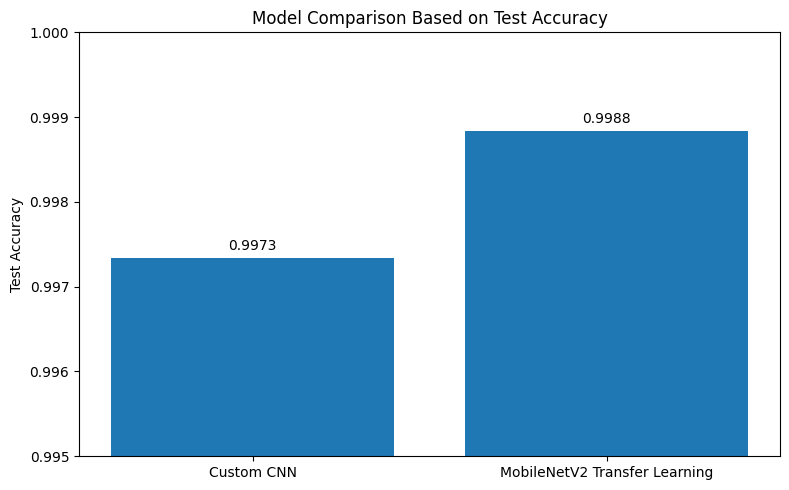

In [28]:
plt.figure(figsize=(8, 5))
plt.bar(model_comparison_df["Model"], model_comparison_df["Test Accuracy"])

plt.ylabel("Test Accuracy")
plt.title("Model Comparison Based on Test Accuracy")
plt.ylim(0.995, 1.0)

for i, value in enumerate(model_comparison_df["Test Accuracy"]):
    plt.text(i, value + 0.0001, f"{value:.4f}", ha="center")

plt.tight_layout()
plt.savefig(figures_dir / "model_comparison_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

## 27. Grad CAM Explainability for the Custom CNN

In this section, Grad CAM is applied to the custom CNN model to visualize which image regions influenced the model's predictions. This explainability step helps evaluate whether the model focuses on crack like structures or irrelevant texture regions when classifying concrete surface images.

In [29]:
last_conv_layer_name = None

for layer in reversed(best_custom_cnn.layers):
    if isinstance(layer, layers.Conv2D):
        last_conv_layer_name = layer.name
        break

print("Last convolution layer for Custom CNN Grad CAM:", last_conv_layer_name)

Last convolution layer for Custom CNN Grad CAM: conv2d_3


## 28. Custom CNN Grad CAM Forward Function

In this section, a custom Grad CAM forward function is created for the saved Custom CNN model. This function extracts the feature maps from the last convolutional layer and connects them to the final prediction output for Grad CAM heatmap generation.

In [30]:

dummy_input = tf.zeros((1, IMG_SIZE, IMG_SIZE, 3))
_ = best_custom_cnn(dummy_input, training=False)

# Find index of the last convolution layer
last_conv_index = None

for i, layer in enumerate(best_custom_cnn.layers):
    if layer.name == last_conv_layer_name:
        last_conv_index = i
        break

print("Last convolution layer name:", last_conv_layer_name)
print("Last convolution layer index:", last_conv_index)

# Layers before and including the last convolution layer
feature_layers = best_custom_cnn.layers[:last_conv_index + 1]

# Layers after the last convolution layer
classifier_layers = best_custom_cnn.layers[last_conv_index + 1:]

def custom_gradcam_forward(image_tensor):
    x = image_tensor
    
    for layer in feature_layers:
        if isinstance(layer, keras.Sequential):
            x = layer(x, training=False)
        else:
            x = layer(x, training=False)
    
    conv_outputs = x
    
    for layer in classifier_layers:
        if isinstance(layer, layers.Dropout):
            x = layer(x, training=False)
        else:
            x = layer(x, training=False)
    
    predictions = x
    
    return conv_outputs, predictions

print("Custom CNN Grad CAM forward function created successfully.")

Last convolution layer name: conv2d_3
Last convolution layer index: 7
Custom CNN Grad CAM forward function created successfully.


## 29. Grad CAM Sample Selection

In this section, representative test images are selected for Grad CAM visualization. The selected examples include one correct Positive prediction, one correct Negative prediction, one false Positive prediction, and one false Negative prediction to support both explainability and error analysis.

In [31]:
test_results_custom_df = test_df.copy().reset_index(drop=True)

test_results_custom_df["true_label_encoded"] = y_true
test_results_custom_df["predicted_label_encoded"] = y_pred_custom
test_results_custom_df["predicted_probability_positive"] = y_prob_custom.ravel()

test_results_custom_df["true_label"] = test_results_custom_df["true_label_encoded"].map({0: "Negative", 1: "Positive"})
test_results_custom_df["predicted_label"] = test_results_custom_df["predicted_label_encoded"].map({0: "Negative", 1: "Positive"})

true_positive_custom = test_results_custom_df[
    (test_results_custom_df["true_label_encoded"] == 1) &
    (test_results_custom_df["predicted_label_encoded"] == 1)
].head(1)

true_negative_custom = test_results_custom_df[
    (test_results_custom_df["true_label_encoded"] == 0) &
    (test_results_custom_df["predicted_label_encoded"] == 0)
].head(1)

false_positive_custom = test_results_custom_df[
    (test_results_custom_df["true_label_encoded"] == 0) &
    (test_results_custom_df["predicted_label_encoded"] == 1)
].head(1)

false_negative_custom = test_results_custom_df[
    (test_results_custom_df["true_label_encoded"] == 1) &
    (test_results_custom_df["predicted_label_encoded"] == 0)
].head(1)

gradcam_custom_samples = pd.concat(
    [
        true_positive_custom,
        true_negative_custom,
        false_positive_custom,
        false_negative_custom
    ],
    axis=0
).reset_index(drop=True)

gradcam_custom_samples[
    [
        "image_path",
        "true_label",
        "predicted_label",
        "predicted_probability_positive"
    ]
]

,image_path,true_label,predicted_label,predicted_probability_positive
0,/kaggle/input/datasets/arnavr10880/concrete-cr...,Positive,Positive,0.999969
1,/kaggle/input/datasets/arnavr10880/concrete-cr...,Negative,Negative,0.000110
2,/kaggle/input/datasets/arnavr10880/concrete-cr...,Negative,Positive,0.953477
3,/kaggle/input/datasets/arnavr10880/concrete-cr...,Positive,Negative,0.020721


## 30. Grad CAM Heatmap Generation and Visualization

In this section, Grad CAM heatmaps are generated for the selected test images. The original image, Grad CAM heatmap, and overlay visualization are shown side by side. These visualizations help interpret the Custom CNN model by showing which regions contributed most to its predictions.

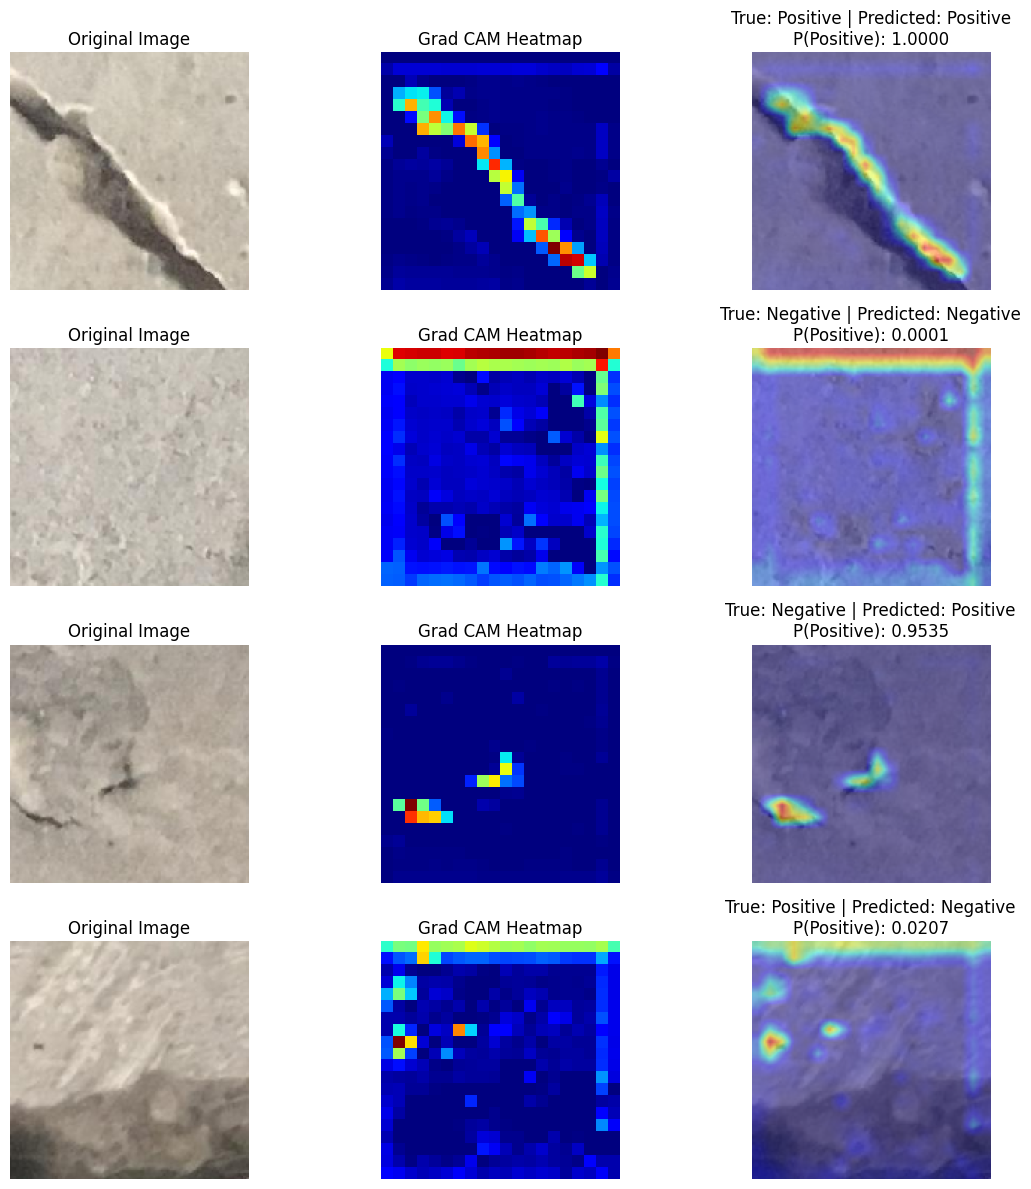

In [32]:
def load_image_for_gradcam(image_path):
    image = keras.utils.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    image_array = keras.utils.img_to_array(image)
    image_array = image_array / 255.0
    return image_array

def make_custom_gradcam_heatmap(image_array, predicted_class):
    image_tensor = np.expand_dims(image_array, axis=0)
    image_tensor = tf.convert_to_tensor(image_tensor, dtype=tf.float32)
    
    with tf.GradientTape() as tape:
        conv_outputs, predictions = custom_gradcam_forward(image_tensor)
        
        if predicted_class == 1:
            class_score = predictions[:, 0]
        else:
            class_score = 1.0 - predictions[:, 0]
    
    gradients = tape.gradient(class_score, conv_outputs)
    pooled_gradients = tf.reduce_mean(gradients, axis=(0, 1, 2))
    
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_gradients, axis=-1)
    
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    
    return heatmap.numpy()

def overlay_heatmap_on_image(image_array, heatmap, alpha=0.45):
    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        (IMG_SIZE, IMG_SIZE)
    ).numpy().squeeze()
    
    colored_heatmap = plt.cm.jet(heatmap_resized)[..., :3]
    overlay = (1 - alpha) * image_array + alpha * colored_heatmap
    overlay = np.clip(overlay, 0, 1)
    
    return overlay

plt.figure(figsize=(12, 12))

for idx, row in gradcam_custom_samples.iterrows():
    image_array = load_image_for_gradcam(row["image_path"])
    predicted_class = int(row["predicted_label_encoded"])
    
    heatmap = make_custom_gradcam_heatmap(image_array, predicted_class)
    overlay = overlay_heatmap_on_image(image_array, heatmap)
    
    title_text = (
        f"True: {row['true_label']} | Predicted: {row['predicted_label']}\n"
        f"P(Positive): {row['predicted_probability_positive']:.4f}"
    )
    
    plt.subplot(len(gradcam_custom_samples), 3, idx * 3 + 1)
    plt.imshow(image_array)
    plt.title("Original Image")
    plt.axis("off")
    
    plt.subplot(len(gradcam_custom_samples), 3, idx * 3 + 2)
    plt.imshow(heatmap, cmap="jet")
    plt.title("Grad CAM Heatmap")
    plt.axis("off")
    
    plt.subplot(len(gradcam_custom_samples), 3, idx * 3 + 3)
    plt.imshow(overlay)
    plt.title(title_text)
    plt.axis("off")

plt.tight_layout()
plt.savefig(figures_dir / "custom_cnn_gradcam_examples.png", dpi=300, bbox_inches="tight")
plt.show()

## 31. Saved Output Files

In this final section, all generated figures, tables, and saved models are listed. This confirms that the notebook successfully produced the required outputs for the GitHub repository and Phase 2 submission.

In [33]:
print("Saved figures:")
for file in sorted(figures_dir.glob("*")):
    print(file.name)

Saved figures:
custom_cnn_accuracy_curve.png
custom_cnn_confusion_matrix.png
custom_cnn_gradcam_examples.png
custom_cnn_loss_curve.png
mobilenetv2_accuracy_curve.png
mobilenetv2_confusion_matrix.png
mobilenetv2_loss_curve.png
model_comparison_accuracy.png
